In [1]:
!pip install "protobuf>=4.25.3,<5.0.0" --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 9.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 4.25.8 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydriv

In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import time
import psutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input 
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

2025-12-02 14:13:06.932397: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764684787.145908      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764684787.206379      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_FROZEN = 10
EPOCHS_FINE_TUNE = 40
DATA_DIR = '/kaggle/input/trashnet/dataset-resized'

In [4]:
def create_dataframe(data_path):
    filepaths = []
    labels = []
    classes = sorted(os.listdir(data_path))
    for class_name in classes:
        class_path = os.path.join(data_path, class_name)
        if os.path.isdir(class_path):
            for file in sorted(os.listdir(class_path)): 
                filepaths.append(os.path.join(class_path, file))
                labels.append(class_name)
    return pd.DataFrame({'filepath': filepaths, 'label': labels})

print("Processing dataset and balancing 'Trash' class...")
df = create_dataframe(DATA_DIR)
train_df, temp_df = train_test_split(df, train_size=0.7, shuffle=True, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, train_size=0.5, shuffle=True, random_state=42, stratify=temp_df['label'])
trash_samples = train_df[train_df['label'] == 'trash']
train_df_balanced = pd.concat([train_df] + [trash_samples] * 4, ignore_index=True)
train_df_balanced = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Original Training Size: {len(train_df)}")
print(f"Balanced Training Size (Trash augmented): {len(train_df_balanced)}")
print(f"Data Split Summary:")
print(f"Training:   {len(train_df)} images (70%)")
print(f"Validation: {len(val_df)} images (15%)")
print(f"Testing:    {len(test_df)} images (15%)")

Processing dataset and balancing 'Trash' class...
Original Training Size: 1768
Balanced Training Size (Trash augmented): 2152
Data Split Summary:
Training:   1768 images (70%)
Validation: 379 images (15%)
Testing:    380 images (15%)


In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # ResNet Specific
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [6]:
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df_balanced,
    x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)

Found 2152 validated image filenames belonging to 6 classes.


In [7]:
validation_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

Found 379 validated image filenames belonging to 6 classes.


In [8]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

Found 380 validated image filenames belonging to 6 classes.


In [9]:
# ... (Keep your existing imports and Data Prep code) ...

# --- IMPROVED MODEL ARCHITECTURE (Strategy 2) ---
from tensorflow.keras.layers import BatchNormalization, Activation

def build_resnet_model(num_classes):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False 
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    
    # IMPROVEMENT: Add BatchNormalization before Activation
    x = Dense(512, use_bias=False)(x) # bias is redundant with BN
    x = BatchNormalization()(x)       # Stabilizes training
    x = Activation('relu')(x)
    
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    
    return base_model, Model(inputs=base_model.input, outputs=predictions)

base_model, model = build_resnet_model(num_classes=6)

# --- STAGE 1: FROZEN (Same as before) ---
print("\n--- STAGE 1: Training Frozen Layers ---")
model.compile(optimizer=Adam(learning_rate=1e-3), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True), # Increased patience slightly
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

history_frozen = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks
)

# --- STAGE 2: DEEPER FINE-TUNING (Strategy 1) ---
print("\n--- STAGE 2: Fine-Tuning Top 20% ---")
base_model.trainable = True

# IMPROVEMENT: Unfreeze top 20% instead of 5%
total_layers = len(base_model.layers)
freeze_until = int(total_layers * 0.80)  # Freeze bottom 80%, Train top 20%

print(f"Total Layers: {total_layers}")
print(f"Freezing bottom {freeze_until} layers. Training top {total_layers - freeze_until} layers.")

for layer in base_model.layers[:freeze_until]: 
    layer.trainable = False

# Use a slightly lower LR to prevent destroying the new deeper weights
model.compile(optimizer=Adam(learning_rate=5e-6), # Lowered from 1e-5 to 5e-6 for safety
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=callbacks
)

I0000 00:00:1764684815.720678      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764684815.721373      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- STAGE 1: Training Frozen Layers ---


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1764684828.758774      99 service.cc:148] XLA service 0x784ad0002e00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764684828.759895      99 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764684828.759921      99 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764684830.490319      99 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/68 ━━━━━━━━━━━━━━━━━━━━ 17:28 16s/step - accuracy: 0.1562 - loss: 2.2985

I0000 00:00:1764684835.893033      99 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


68/68 ━━━━━━━━━━━━━━━━━━━━ 68s 784ms/step - accuracy: 0.6486 - loss: 1.1077 - val_accuracy: 0.8443 - val_loss: 0.4669 - learning_rate: 0.0010
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 29s 430ms/step - accuracy: 0.8648 - loss: 0.3739 - val_accuracy: 0.8734 - val_loss: 0.3700 - learning_rate: 0.0010
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 30s 433ms/step - accuracy: 0.9076 - loss: 0.2536 - val_accuracy: 0.8892 - val_loss: 0.3793 - learning_rate: 0.0010
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 29s 427ms/step - accuracy: 0.9207 - loss: 0.2244 - val_accuracy: 0.8654 - val_loss: 0.4073 - learning_rate: 0.0010
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 29s 431ms/step - accuracy: 0.9350 - loss: 0.1824 - val_accuracy: 0.8892 - val_loss: 0.3371 - learning_rate: 0.0010
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 29s 425ms/step - accuracy: 0.9502 - loss: 0.1469 - val_accuracy: 0.9129 - val_loss: 0.3008 - learning_rate: 0.0010
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 29s 423ms/step - accuracy: 0.9507 - loss: 0.1384 - val_

Generating Learning Curves...


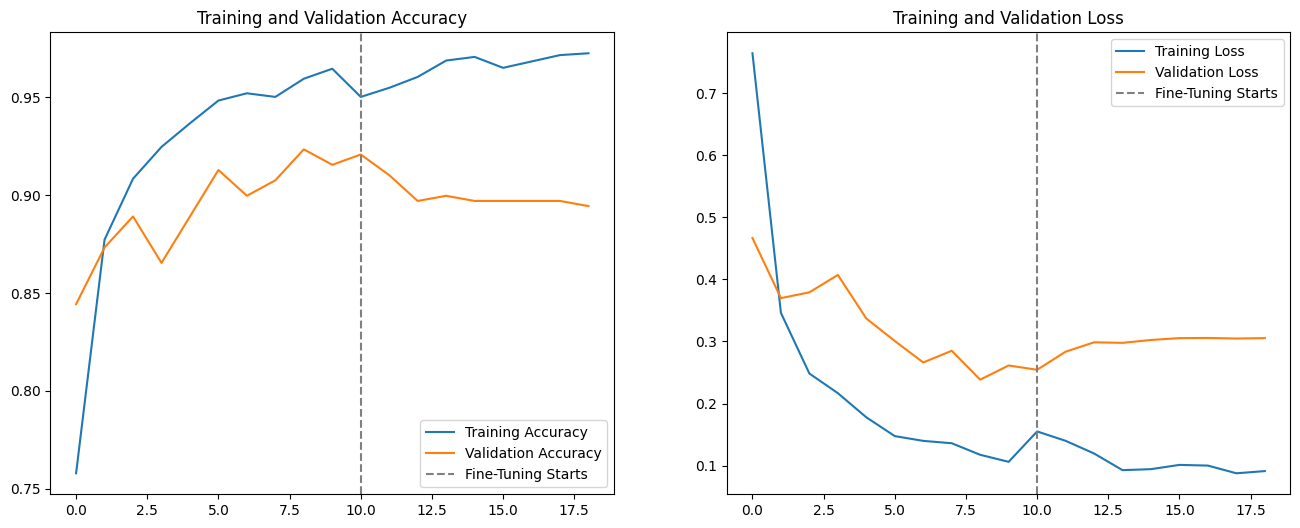


Generating Predictions for Detailed Metrics...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 893ms/step


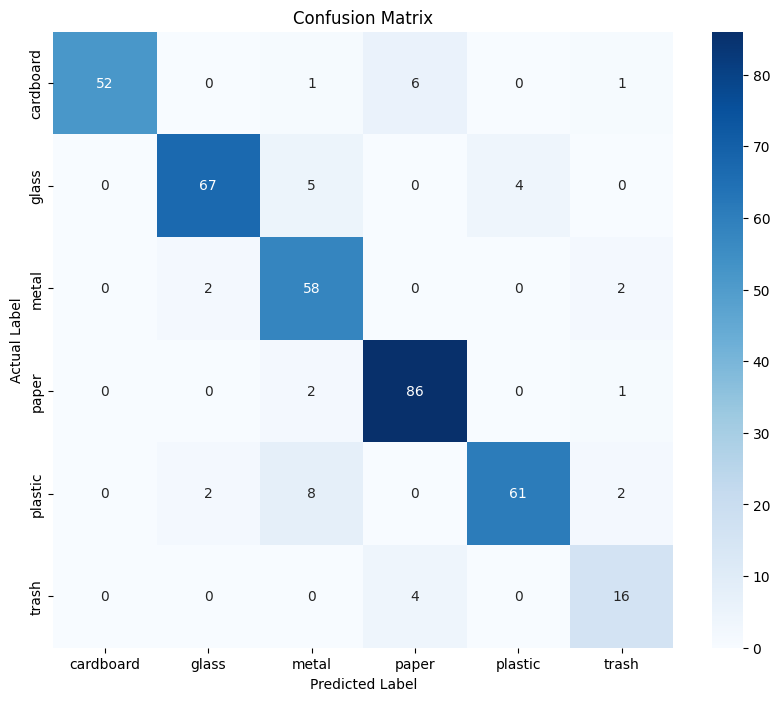


--- Detailed Evaluation Metrics per Class (Based on Lecture 10) ---
    Class  Accuracy  Error Rate  Sensitivity (Recall)  Specificity (TNR)  False Pos. Rate  Precision  F-Score  Prevalence
cardboard    0.9789      0.0211                0.8667             1.0000           0.0000     1.0000   0.9286      0.1579
    glass    0.9658      0.0342                0.8816             0.9868           0.0132     0.9437   0.9116      0.2000
    metal    0.9474      0.0526                0.9355             0.9497           0.0503     0.7838   0.8529      0.1632
    paper    0.9658      0.0342                0.9663             0.9656           0.0344     0.8958   0.9297      0.2342
  plastic    0.9579      0.0421                0.8356             0.9870           0.0130     0.9385   0.8841      0.1921
    trash    0.9737      0.0263                0.8000             0.9833           0.0167     0.7273   0.7619      0.0526

Global Model Accuracy: 0.8947


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

# --- 1. PLOTTING LEARNING CURVES [cite: 149] ---
# We combine the history from both stages to see the full picture
def plot_learning_curves(hist1, hist2):
    acc = hist1.history['accuracy'] + hist2.history['accuracy']
    val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss = hist1.history['loss'] + hist2.history['loss']
    val_loss = hist1.history['val_loss'] + hist2.history['val_loss']
    
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.axvline(x=10, color='gray', linestyle='--', label='Fine-Tuning Starts')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Loss Plot 
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.axvline(x=10, color='gray', linestyle='--', label='Fine-Tuning Starts')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

print("Generating Learning Curves...")
plot_learning_curves(history_frozen, history_finetune)

# --- 2. GENERATE PREDICTIONS ---
print("\nGenerating Predictions for Detailed Metrics...")
# Get predictions
Y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# --- 3. CONFUSION MATRIX [cite: 120] ---
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# --- 4. DETAILED METRICS FROM LECTURE  ---
# Calculating TP, TN, FP, FN for each class (One-vs-All approach)
metrics_list = []

for i, label in enumerate(class_labels):
    # True Positives (TP): Correctly predicted as Class i
    TP = cm[i, i]
    
    # False Positives (FP): Predicted as Class i, but actually not
    FP = cm[:, i].sum() - TP
    
    # False Negatives (FN): Actually Class i, but predicted as something else
    FN = cm[i, :].sum() - TP
    
    # True Negatives (TN): Actually not Class i, and predicted as not Class i
    TN = cm.sum() - (TP + FP + FN)
    
    # Total samples for this calculation
    Total = TP + TN + FP + FN
    
    # --- Metrics Formulas from Slides ---
    # Accuracy[cite: 119, 133]: (TP + TN) / Total
    Class_Accuracy = (TP + TN) / Total
    
    # Misclassification Rate / Error Rate: (FP + FN) / Total
    Error_Rate = (FP + FN) / Total
    
    # Sensitivity / Recall / TPR[cite: 133, 138]: TP / (TP + FN)
    Sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    
    # Specificity / True Negative Rate: TN / (TN + FP)
    Specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    # False Positive Rate: FP / (TN + FP)
    FPR = FP / (TN + FP) if (TN + FP) > 0 else 0
    
    # Precision[cite: 133, 144]: TP / (TP + FP)
    Precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    
    # F-Score[cite: 148]: 2 * (Precision * Recall) / (Precision + Recall)
    if (Precision + Sensitivity) > 0:
        F_Score = 2 * (Precision * Sensitivity) / (Precision + Sensitivity)
    else:
        F_Score = 0
        
    # Prevalence: (TP + FN) / Total (Actual Yes / Total)
    Prevalence = (TP + FN) / Total

    metrics_list.append({
        'Class': label,
        'Accuracy': round(Class_Accuracy, 4),
        'Error Rate': round(Error_Rate, 4),
        'Sensitivity (Recall)': round(Sensitivity, 4),
        'Specificity (TNR)': round(Specificity, 4),
        'False Pos. Rate': round(FPR, 4),
        'Precision': round(Precision, 4),
        'F-Score': round(F_Score, 4),
        'Prevalence': round(Prevalence, 4)
    })

# Create a DataFrame to display the results nicely
metrics_df = pd.DataFrame(metrics_list)
print("\n--- Detailed Evaluation Metrics per Class (Based on Lecture 10) ---")
print(metrics_df.to_string(index=False))

# Overall Global Accuracy [cite: 119]
global_acc = accuracy_score(y_true, y_pred_classes)
print(f"\nGlobal Model Accuracy: {global_acc:.4f}")

In [11]:
import threading
import subprocess
import time
import psutil
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input, ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Activation
from tensorflow.keras.models import Model, load_model

# --- 1. HARDWARE MONITOR (Re-defining since session restarted) ---
class HardwareMonitor(threading.Thread):
    def __init__(self, delay=0.1):
        super(HardwareMonitor, self).__init__()
        self.stopped = False
        self.delay = delay
        self.cpu_readings = []
        self.gpu_readings = []
        self.start()

    def run(self):
        while not self.stopped:
            self.cpu_readings.append(psutil.cpu_percent(interval=None))
            try:
                result = subprocess.check_output(
                    ['nvidia-smi', '--query-gpu=utilization.gpu', '--format=csv,noheader,nounits'], 
                    encoding='utf-8'
                )
                self.gpu_readings.append(float(result.strip()))
            except:
                self.gpu_readings.append(0.0)
            time.sleep(self.delay)

    def stop(self):
        self.stopped = True
        
    def get_stats(self):
        avg_cpu = sum(self.cpu_readings) / len(self.cpu_readings) if self.cpu_readings else 0
        avg_gpu = sum(self.gpu_readings) / len(self.gpu_readings) if self.gpu_readings else 0
        return avg_cpu, avg_gpu

# --- 2. RECOVER MODEL (Load or Rebuild) ---
model_filename = 'resnet50_trashnet_balanced.keras'

if os.path.exists(model_filename):
    print(f"Found saved model: {model_filename}. Loading...")
    model = load_model(model_filename)
else:
    print("Saved model file not found (session wiped). Re-building ResNet50 architecture for speed test...")
    # Rebuild the exact same structure (Weights don't affect speed, only structure does)
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(6, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    print("ResNet50 Architecture rebuilt.")

# --- 3. RUN BENCHMARK ---
def measure_inference_with_usage(device_name, num_samples=2000):
    print(f"[{device_name}] Generating {num_samples} dummy images...")
    dummy_input = np.random.rand(num_samples, 224, 224, 3).astype(np.float32) * 255.0
    dummy_input = preprocess_input(dummy_input)
    
    print(f"[{device_name}] Warming up...")
    _ = model.predict(dummy_input[:32], verbose=0)
    
    monitor = HardwareMonitor(delay=0.1)
    
    print(f"[{device_name}] Running inference loop...")
    start_time = time.time()
    _ = model.predict(dummy_input, verbose=0, batch_size=32)
    end_time = time.time()
    
    monitor.stop()
    monitor.join()
    
    avg_cpu, avg_gpu = monitor.get_stats()
    total_time = end_time - start_time
    per_image = total_time / num_samples
    
    print(f"\n--- {device_name} PERFORMANCE RESULTS ({num_samples} Images) ---")
    print(f"Time Total:   {total_time:.4f}s")
    print(f"Per Image:    {per_image:.4f}s")
    print(f"FPS:          {1/per_image:.2f}")
    print(f"Avg CPU Util: {avg_cpu:.1f}%")
    print(f"Avg GPU Util: {avg_gpu:.1f}%")

# Execute
try:
    if tf.config.list_physical_devices('GPU'):
        with tf.device('/GPU:0'):
            measure_inference_with_usage("GPU", num_samples=2000)
    else:
        print("No GPU detected.")
except Exception as e:
    print(f"Error: {e}")

Saved model file not found (session wiped). Re-building ResNet50 architecture for speed test...
ResNet50 Architecture rebuilt.
[GPU] Generating 2000 dummy images...
[GPU] Warming up...
[GPU] Running inference loop...

--- GPU PERFORMANCE RESULTS (2000 Images) ---
Time Total:   14.8287s
Per Image:    0.0074s
FPS:          134.87
Avg CPU Util: 31.3%
Avg GPU Util: 0.0%
